In [1]:
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'

import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error
import pickle

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

pd.set_option('display.max_columns', None)
plt.style.use('seaborn-v0_8-darkgrid')
%matplotlib inline

print(f"Libraries imported")
print(f"Device: {device}")
print(f"GPU: {torch.cuda.get_device_name(0)}")

Libraries imported
Device: cuda
GPU: NVIDIA GeForce RTX 5090


In [2]:
ratings = pd.read_csv('../data/ml-25m/ratings.csv')
ratings['datetime'] = pd.to_datetime(ratings['timestamp'], unit='s')

split_date = '2015-01-01'
train = ratings[ratings['datetime'] < split_date].copy()
test = ratings[ratings['datetime'] >= split_date].copy()

# Normalize ratings to 0-1 scale
min_rating = 0.5
max_rating = 5.0
train['rating'] = (train['rating'] - min_rating) / (max_rating - min_rating)
test['rating'] = (test['rating'] - min_rating) / (max_rating - min_rating)

print(f"Train: {len(train):,} ratings")
print(f"Test: {len(test):,} ratings")
print(f"Rating range: {train['rating'].min():.2f} - {train['rating'].max():.2f}")

Train: 17,436,354 ratings
Test: 7,563,741 ratings
Rating range: 0.00 - 1.00


In [3]:
user_ids = train['userId'].unique()
movie_ids = train['movieId'].unique()

user_id_to_index = {user_id: idx for idx, user_id in enumerate(user_ids)}
movie_id_to_index = {movie_id: idx for idx, movie_id in enumerate(movie_ids)}

index_to_user_id = {idx: user_id for user_id, idx in user_id_to_index.items()}
index_to_movie_id = {idx: movie_id for movie_id, idx in movie_id_to_index.items()}

train['user_index'] = train['userId'].map(user_id_to_index)
train['movie_index'] = train['movieId'].map(movie_id_to_index)
test['user_index'] = test['userId'].map(user_id_to_index)
test['movie_index'] = test['movieId'].map(movie_id_to_index)

n_users = len(user_ids)
n_movies = len(movie_ids)

print(f"Number of users:  {n_users:,}")
print(f"Number of movies: {n_movies:,}")
print(f"Test cold start users: {test['user_index'].isna().sum():,}")

Number of users:  121,673
Number of movies: 22,316
Test cold start users: 6,836,326


In [4]:
class MovieRatingDataset(Dataset):
    def __init__(self, dataframe):
        valid = dataframe['user_index'].notna() & dataframe['movie_index'].notna()
        dataframe = dataframe[valid].reset_index(drop=True)
        
        self.users = torch.tensor(
            dataframe['user_index'].values, dtype=torch.long)
        self.movies = torch.tensor(
            dataframe['movie_index'].values, dtype=torch.long)
        self.ratings = torch.tensor(
            dataframe['rating'].values, dtype=torch.float32)
        
    def __len__(self):
        return len(self.ratings)
    
    def __getitem__(self, idx):
        return self.users[idx], self.movies[idx], self.ratings[idx]

# Create datasets
train_dataset = MovieRatingDataset(train)
test_dataset = MovieRatingDataset(test)

# Optimized DataLoader
train_loader = DataLoader(
    train_dataset,
    batch_size=4096,
    shuffle=True,
    num_workers=0,
    pin_memory=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=4096,
    shuffle=False,
    num_workers=0,
    pin_memory=False
)

print(f"Train dataset: {len(train_dataset):,}")
print(f"Test dataset:  {len(test_dataset):,}")
print(f"Train batches: {len(train_loader):,}")
print(f"Batch size:    4,096")

Train dataset: 17,436,354
Test dataset:  546,990
Train batches: 4,257
Batch size:    4,096


In [5]:
def calculate_rmse(actual, predicted):
    return np.sqrt(mean_squared_error(actual, predicted))

def calculate_mae(actual, predicted):
    return mean_absolute_error(actual, predicted)

def train_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0
    
    for user, movie, rating in loader:
        user = user.to(device)
        movie = movie.to(device)
        rating = rating.to(device)
        
        predictions = model(user, movie)
        loss = criterion(predictions, rating)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
    
    return total_loss / len(loader)

def evaluate(model, loader, criterion):
    model.eval()
    total_loss = 0
    all_predictions = []
    all_actuals = []
    
    with torch.no_grad():
        for user, movie, rating in loader:
            user = user.to(device)
            movie = movie.to(device)
            rating = rating.to(device)
            
            predictions = model(user, movie)
            loss = criterion(predictions, rating)
            total_loss += loss.item()
            
            all_predictions.extend(predictions.cpu().numpy())
            all_actuals.extend(rating.cpu().numpy())
    
    rmse = np.sqrt(mean_squared_error(all_actuals, all_predictions))
    mae = mean_absolute_error(all_actuals, all_predictions)
    
    return total_loss / len(loader), rmse, mae

print("Metric functions and training loop")

Metric functions and training loop


In [6]:
class GMF(nn.Module):
    def __init__(self, n_users, n_movies, embedding_dim=32):
        super(GMF, self).__init__()
        
        # User and movie embedding layers
        self.user_embedding = nn.Embedding(n_users, embedding_dim)
        self.movie_embedding = nn.Embedding(n_movies, embedding_dim)
        
        # Initialization
        nn.init.normal_(self.user_embedding.weight, std=0.1)
        nn.init.normal_(self.movie_embedding.weight, std=0.1)
        
        # Single output layer
        self.output_layer = nn.Linear(embedding_dim, 1)
        
    def forward(self, user_indices, movie_indices):
        # Look up embeddings
        user_vec = self.user_embedding(user_indices)
        movie_vec = self.movie_embedding(movie_indices) 
        
        # Element-wise multiplication
        interaction = user_vec * movie_vec             
        
        # Single linear layer
        output = self.output_layer(interaction)         
        
        return output.squeeze()

# Initialize model
model = GMF(n_users, n_movies, embedding_dim=32).to(device)
total_params = sum(p.numel() for p in model.parameters())

print(f"Model initialized on: {device}")
print(f"Embedding dimension:  32")
print(f"Total parameters:     {total_params:,}")
print(f"\nArchitecture:")
print(model)

Model initialized on: cuda
Embedding dimension:  32
Total parameters:     4,607,681

Architecture:
GMF(
  (user_embedding): Embedding(121673, 32)
  (movie_embedding): Embedding(22316, 32)
  (output_layer): Linear(in_features=32, out_features=1, bias=True)
)


In [7]:
criterion = nn.MSELoss()

optimizer = torch.optim.Adam([
    {'params': model.user_embedding.parameters(), 'lr': 0.005},
    {'params': model.movie_embedding.parameters(), 'lr': 0.005},
    {'params': model.output_layer.parameters(), 'lr': 0.001},
])

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=2
)

print("Optimizer: Adam with layer-specific learning rates")
print("Scheduler: ReduceLROnPlateau")
print(f"  Embedding LR: 0.005")
print(f"  Output LR:    0.001")
print(f"  Factor:       0.5")
print(f"  Patience:     2")

Optimizer: Adam with layer-specific learning rates
Scheduler: ReduceLROnPlateau
  Embedding LR: 0.005
  Output LR:    0.001
  Factor:       0.5
  Patience:     2


In [8]:
N_EPOCHS = 10
best_rmse = float('inf')
train_losses = []
test_rmses = []
learning_rates = []

print(f"Starting GMF training for {N_EPOCHS} epochs...")
print(f"Device: {device}")
print("="*60)

for epoch in range(N_EPOCHS):
    train_loss = train_epoch(model, train_loader, optimizer, criterion)
    test_loss, test_rmse, test_mae = evaluate(model, test_loader, criterion)
    
    rmse_original = test_rmse * (max_rating - min_rating)
    mae_original = test_mae * (max_rating - min_rating)
    
    train_losses.append(train_loss)
    test_rmses.append(rmse_original)
    
    # Step scheduler then read updated LR
    scheduler.step(test_rmse)
    current_lr = optimizer.param_groups[0]['lr']
    learning_rates.append(current_lr)
    
    if rmse_original < best_rmse:
        best_rmse = rmse_original
        torch.save(model.state_dict(), '../models/gmf_best_model.pth')
        saved = "Saved"
    else:
        saved = ""
    
    print(f"Epoch {epoch+1:2d}/{N_EPOCHS} | "
          f"Train Loss: {train_loss:.4f} | "
          f"Test RMSE: {rmse_original:.4f} | "
          f"LR: {current_lr:.5f} | {saved}")

print("="*60)
print(f"Training complete!")
print(f"Best GMF RMSE:     {best_rmse:.4f}")
print(f"NCF Notebook 5:    0.8385")
print(f"SVD Benchmark:     0.9795")

Starting GMF training for 10 epochs...
Device: cuda
Epoch  1/10 | Train Loss: 0.0461 | Test RMSE: 0.8497 | LR: 0.00500 | Saved
Epoch  2/10 | Train Loss: 0.0289 | Test RMSE: 0.8394 | LR: 0.00500 | Saved
Epoch  3/10 | Train Loss: 0.0262 | Test RMSE: 0.8408 | LR: 0.00500 | 
Epoch  4/10 | Train Loss: 0.0247 | Test RMSE: 0.8484 | LR: 0.00500 | 
Epoch  5/10 | Train Loss: 0.0238 | Test RMSE: 0.8536 | LR: 0.00250 | 
Epoch  6/10 | Train Loss: 0.0219 | Test RMSE: 0.8610 | LR: 0.00250 | 
Epoch  7/10 | Train Loss: 0.0215 | Test RMSE: 0.8658 | LR: 0.00250 | 
Epoch  8/10 | Train Loss: 0.0213 | Test RMSE: 0.8689 | LR: 0.00125 | 
Epoch  9/10 | Train Loss: 0.0204 | Test RMSE: 0.8757 | LR: 0.00125 | 
Epoch 10/10 | Train Loss: 0.0203 | Test RMSE: 0.8801 | LR: 0.00125 | 
Training complete!
Best GMF RMSE:     0.8394
NCF Notebook 5:    0.8385
SVD Benchmark:     0.9795


In [9]:
class GMF_Regularized(nn.Module):
    def __init__(self, n_users, n_movies, embedding_dim=32, dropout=0.3):
        super(GMF_Regularized, self).__init__()
        
        self.user_embedding = nn.Embedding(n_users, embedding_dim)
        self.movie_embedding = nn.Embedding(n_movies, embedding_dim)
        
        nn.init.normal_(self.user_embedding.weight, std=0.1)
        nn.init.normal_(self.movie_embedding.weight, std=0.1)
        
        self.dropout = nn.Dropout(p=dropout)
        self.bn = nn.BatchNorm1d(embedding_dim)
        self.output_layer = nn.Linear(embedding_dim, 1)
        
    def forward(self, user_indices, movie_indices):
        user_vec = self.user_embedding(user_indices)
        movie_vec = self.movie_embedding(movie_indices)
        
        # Element-wise multiplication
        interaction = user_vec * movie_vec
        
        # Add regularization
        interaction = self.dropout(self.bn(interaction))
        
        output = self.output_layer(interaction)
        
        return output.squeeze()

# Initialize regularized model
model_reg = GMF_Regularized(n_users, n_movies, embedding_dim=32, dropout=0.3).to(device)
total_params = sum(p.numel() for p in model_reg.parameters())

print(f"GMF Regularized initialized on: {device}")
print(f"Embedding dimension: 32")
print(f"Dropout:             0.3")
print(f"Batch normalization: Yes")
print(f"Total parameters:    {total_params:,}")
print(f"\nArchitecture:")
print(model_reg)

GMF Regularized initialized on: cuda
Embedding dimension: 32
Dropout:             0.3
Batch normalization: Yes
Total parameters:    4,607,745

Architecture:
GMF_Regularized(
  (user_embedding): Embedding(121673, 32)
  (movie_embedding): Embedding(22316, 32)
  (dropout): Dropout(p=0.3, inplace=False)
  (bn): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (output_layer): Linear(in_features=32, out_features=1, bias=True)
)


In [10]:
criterion_reg = nn.MSELoss()

optimizer_reg = torch.optim.Adam([
    {'params': model_reg.user_embedding.parameters(), 'lr': 0.005},
    {'params': model_reg.movie_embedding.parameters(), 'lr': 0.005},
    {'params': model_reg.output_layer.parameters(), 'lr': 0.001},
    {'params': model_reg.bn.parameters(), 'lr': 0.001},
])

scheduler_reg = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_reg,
    mode='min',
    factor=0.5,
    patience=2
)

N_EPOCHS = 10
best_rmse_reg = float('inf')
train_losses_reg = []
test_rmses_reg = []
learning_rates_reg = []

print(f"Training Regularized GMF for {N_EPOCHS} epochs...")
print("="*60)

for epoch in range(N_EPOCHS):
    train_loss = train_epoch(model_reg, train_loader, optimizer_reg, criterion_reg)
    test_loss, test_rmse, test_mae = evaluate(model_reg, test_loader, criterion_reg)
    
    rmse_original = test_rmse * (max_rating - min_rating)
    mae_original = test_mae * (max_rating - min_rating)
    
    train_losses_reg.append(train_loss)
    test_rmses_reg.append(rmse_original)
    
    scheduler_reg.step(test_rmse)
    current_lr = optimizer_reg.param_groups[0]['lr']
    learning_rates_reg.append(current_lr)
    
    if rmse_original < best_rmse_reg:
        best_rmse_reg = rmse_original
        torch.save(model_reg.state_dict(), '../models/gmf_regularized_best.pth')
        saved = "Saved"
    else:
        saved = ""
    
    print(f"Epoch {epoch+1:2d}/{N_EPOCHS} | "
          f"Train Loss: {train_loss:.4f} | "
          f"Test RMSE: {rmse_original:.4f} | "
          f"LR: {current_lr:.5f} | {saved}")

print("="*60)
print(f"Training complete!")
print(f"Best Regularized GMF RMSE: {best_rmse_reg:.4f}")
print(f"Original GMF RMSE:         0.8394")
print(f"NCF Notebook 5 RMSE:       0.8385")
print(f"SVD Benchmark:             0.9795")

Training Regularized GMF for 10 epochs...
Epoch  1/10 | Train Loss: 0.0717 | Test RMSE: 0.8805 | LR: 0.00500 | Saved
Epoch  2/10 | Train Loss: 0.0359 | Test RMSE: 0.8554 | LR: 0.00500 | Saved
Epoch  3/10 | Train Loss: 0.0328 | Test RMSE: 0.8446 | LR: 0.00500 | Saved
Epoch  4/10 | Train Loss: 0.0310 | Test RMSE: 0.8420 | LR: 0.00500 | Saved
Epoch  5/10 | Train Loss: 0.0300 | Test RMSE: 0.8398 | LR: 0.00500 | Saved
Epoch  6/10 | Train Loss: 0.0294 | Test RMSE: 0.8382 | LR: 0.00500 | Saved
Epoch  7/10 | Train Loss: 0.0290 | Test RMSE: 0.8373 | LR: 0.00500 | Saved
Epoch  8/10 | Train Loss: 0.0286 | Test RMSE: 0.8352 | LR: 0.00500 | Saved
Epoch  9/10 | Train Loss: 0.0284 | Test RMSE: 0.8340 | LR: 0.00500 | Saved
Epoch 10/10 | Train Loss: 0.0282 | Test RMSE: 0.8368 | LR: 0.00500 | 
Training complete!
Best Regularized GMF RMSE: 0.8340
Original GMF RMSE:         0.8394
NCF Notebook 5 RMSE:       0.8385
SVD Benchmark:             0.9795


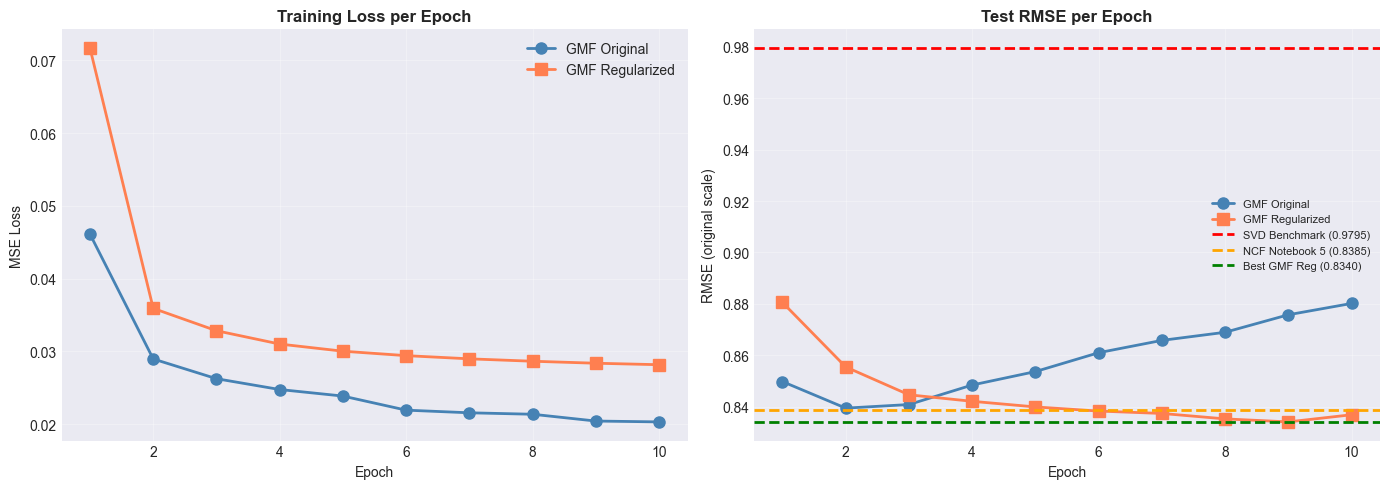


Key Observations:
  GMF Original:     peaked epoch 2 (0.8394) then crashed to 0.8801
  GMF Regularized:  improved 9 consecutive epochs, best 0.8340
  Regularization impact: +0.0054 RMSE improvement + stable training


In [11]:
epochs = range(1, N_EPOCHS + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Training loss - both GMF versions
ax1.plot(epochs, train_losses, marker='o', linewidth=2,
         color='steelblue', markersize=8, label='GMF Original')
ax1.plot(epochs, train_losses_reg, marker='s', linewidth=2,
         color='coral', markersize=8, label='GMF Regularized')
ax1.set_title('Training Loss per Epoch', fontweight='bold')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('MSE Loss')
ax1.legend()
ax1.grid(alpha=0.3)

# Test RMSE - both GMF versions
ax2.plot(epochs, test_rmses, marker='o', linewidth=2,
         color='steelblue', markersize=8, label='GMF Original')
ax2.plot(epochs, test_rmses_reg, marker='s', linewidth=2,
         color='coral', markersize=8, label='GMF Regularized')
ax2.axhline(y=0.9795, color='red', linestyle='--',
            linewidth=2, label='SVD Benchmark (0.9795)')
ax2.axhline(y=0.8385, color='orange', linestyle='--',
            linewidth=2, label='NCF Notebook 5 (0.8385)')
ax2.axhline(y=min(test_rmses_reg), color='green', linestyle='--',
            linewidth=2, label=f'Best GMF Reg ({min(test_rmses_reg):.4f})')
ax2.set_title('Test RMSE per Epoch', fontweight='bold')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('RMSE (original scale)')
ax2.legend(fontsize=8)
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nKey Observations:")
print(f"  GMF Original:     peaked epoch 2 (0.8394) then crashed to 0.8801")
print(f"  GMF Regularized:  improved 9 consecutive epochs, best 0.8340")
print(f"  Regularization impact: +0.0054 RMSE improvement + stable training")

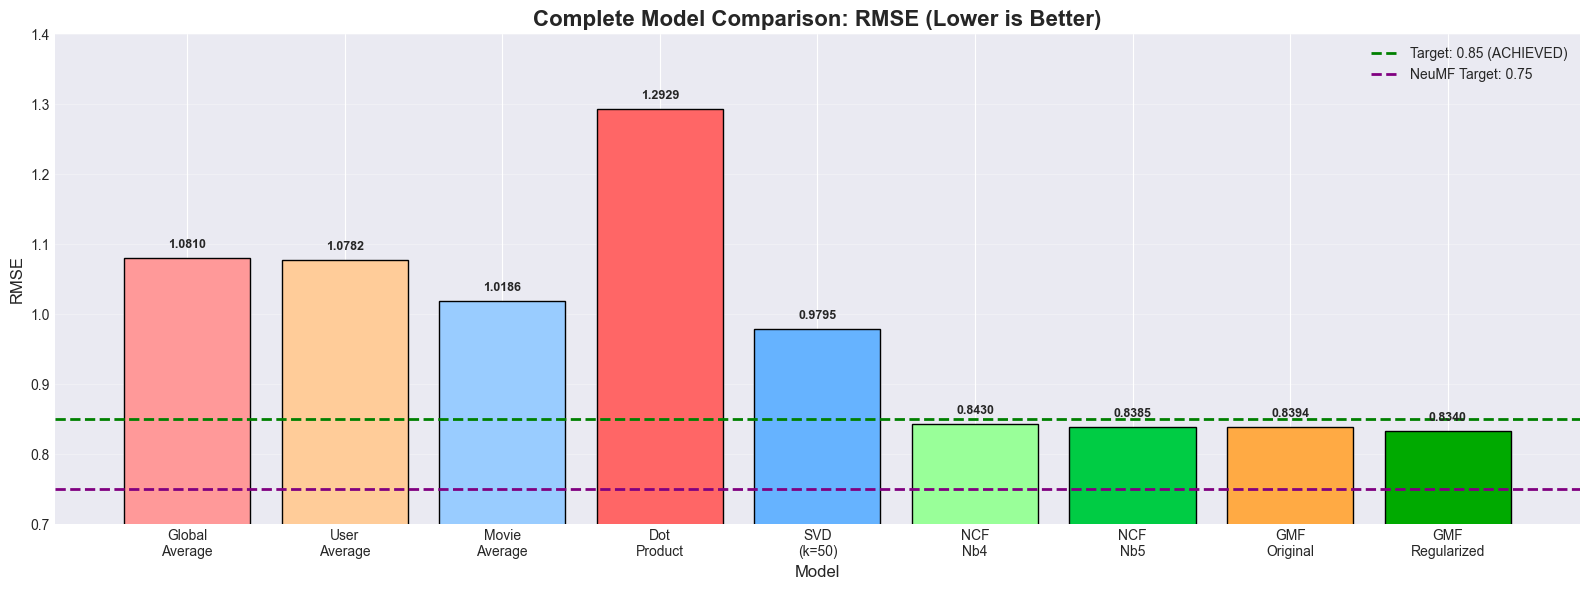


Complete Model Rankings:
  GMF
Regularized      RMSE: 0.8340 
  NCF
Nb5              RMSE: 0.8385 
  GMF
Original         RMSE: 0.8394 
  NCF
Nb4              RMSE: 0.8430 
  SVD
(k=50)           RMSE: 0.9795 
  Movie
Average        RMSE: 1.0186 
  User
Average         RMSE: 1.0782 
  Global
Average       RMSE: 1.0810 
  Dot
Product          RMSE: 1.2929 


In [14]:
models = ['Global\nAverage', 'User\nAverage', 'Movie\nAverage',
          'Dot\nProduct', 'SVD\n(k=50)', 'NCF\nNb4', 'NCF\nNb5',
          'GMF\nOriginal', 'GMF\nRegularized']
rmses = [1.0810, 1.0782, 1.0186, 1.2929, 0.9795, 0.8430, 0.8385, 0.8394, 0.8340]
colors = ['#ff9999', '#ffcc99', '#99ccff', '#ff6666',
          '#66b3ff', '#99ff99', '#00cc44', '#ffaa44', '#00aa00']

plt.figure(figsize=(16, 6))
bars = plt.bar(models, rmses, color=colors, edgecolor='black')
plt.title('Complete Model Comparison: RMSE (Lower is Better)',
          fontsize=16, fontweight='bold')
plt.xlabel('Model', fontsize=12)
plt.ylabel('RMSE', fontsize=12)
plt.ylim(0.7, 1.4)

for bar, rmse in zip(bars, rmses):
    plt.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
             f'{rmse:.4f}', ha='center', va='bottom',
             fontweight='bold', fontsize=9)

plt.axhline(y=0.85, color='green', linestyle='--',
            linewidth=2, label='Target: 0.85 (ACHIEVED)')
plt.axhline(y=0.75, color='purple', linestyle='--',
            linewidth=2, label='NeuMF Target: 0.75')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print("\nComplete Model Rankings:")
print("="*50)
for model, rmse in sorted(zip(models, rmses), key=lambda x: x[1]):
    status = "" if rmse == min(rmses) else ""
    print(f"  {model:20s} RMSE: {rmse:.4f} {status}")

In [15]:
import pickle

os.makedirs('../models', exist_ok=True)

model_info = {
    'n_users': n_users,
    'n_movies': n_movies,
    'embedding_dim': 32,
    'dropout': 0.3,
    'best_rmse': 0.8340,
    'epochs_trained': 10,
    'user_id_to_index': user_id_to_index,
    'movie_id_to_index': movie_id_to_index,
    'index_to_user_id': index_to_user_id,
    'index_to_movie_id': index_to_movie_id,
    'min_rating': min_rating,
    'max_rating': max_rating
}

with open('../models/gmf_regularized_info.pkl', 'wb') as f:
    pickle.dump(model_info, f)

print("Model artifacts")
print(f"  ../models/gmf_best_model.pth          - Original GMF weights")
print(f"  ../models/gmf_regularized_best.pth    - Regularized GMF weights")
print(f"  ../models/gmf_regularized_info.pkl    - Model config and mappings")
print(f"\nModel Configuration:")
print(f"  Embedding dim: 32")
print(f"  Dropout:       0.3")
print(f"  Batch norm:    Yes")
print(f"  Best RMSE:     0.8340")

Model artifacts saved!
  ../models/gmf_best_model.pth          - Original GMF weights
  ../models/gmf_regularized_best.pth    - Regularized GMF weights
  ../models/gmf_regularized_info.pkl    - Model config and mappings

Model Configuration:
  Embedding dim: 32
  Dropout:       0.3
  Batch norm:    Yes
  Best RMSE:     0.8340


## Notebook 6 Summary: GMF Model

### What is GMF?
Generalized Matrix Factorization (GMF) is a neural interpretation of 
matrix factorization. Instead of a dot product like SVD, GMF uses 
element-wise multiplication to combine user and movie embeddings, 
then passes through a single linear layer with learnable weights.
```
SVD:  prediction = sum(user_vec · movie_vec)
GMF:  prediction = linear(user_vec ⊙ movie_vec)
```

The key difference: GMF learns which embedding dimensions matter most
through the output layer weights, rather than treating all dimensions equally.

### Architecture
```
User Index → Embedding (32)   ─┐
                               ⊙ → BatchNorm → Dropout → Linear(32,1) → prediction
Movie Index → Embedding (32)  ─┘
```

### GMF Original vs Regularized
| Component | GMF Original | GMF Regularized |
|-----------|-------------|-----------------|
| Dropout | No | Yes (p=0.3) |
| Batch normalization | No | Yes |
| Best RMSE | 0.8394 (epoch 2) | 0.8340 (epoch 9) |
| Epoch 10 RMSE | 0.8801 (crashed) | 0.8368 (stable) |
| Training pattern | Peak then crash | Consistent improvement |

### Key Finding: Regularization Impact
Without dropout and BatchNorm, GMF memorized training data 
extremely quickly — peaking at epoch 2 then getting worse every 
single epoch, ending at 0.8801. Train loss kept dropping while 
test RMSE climbed — textbook overfitting.

With dropout and BatchNorm, GMF improved for 9 consecutive epochs
with no oscillation — the most stable training we've seen in any model.

### Complete Model Rankings
| Model | RMSE | vs SVD |
|-------|------|--------|
| Global Average | 1.0810 | Baseline |
| User Average | 1.0782 | +0.26% |
| Movie Average | 1.0186 | +5.78% |
| Dot Product | 1.2929 | Worse |
| SVD (k=50) | 0.9795 | — |
| NCF Notebook 4 | 0.8430 | +13.94% |
| NCF Notebook 5 | 0.8385 | +14.39% |
| GMF Original | 0.8394 | +14.30% |
| **GMF Regularized** | **0.8340** | **+14.85%** |

### Why GMF Works Better Than Expected
- Element-wise multiplication captures user-movie interactions immediately
- No need for 4 neural network layers like NCF
- Simpler architecture = less overfitting risk with proper regularization
- Faster convergence than NCF (fewer parameters to optimize)

### GMF Limitations
- Still a linear model — can't capture complex non-linear patterns
- Real value is as a component inside NeuMF, not standalone
- Single output layer limits expressiveness